In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

I0000 00:00:1789402221.792094  701036 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789402222.558314  701036 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789402226.550983  701036 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
X_train = pd.read_csv(
    "../data/processed/ml_X_train_final.csv"
)

X_test = pd.read_csv(
    "../data/processed/ml_X_test_final.csv"
)

y_train = pd.read_csv(
    "../data/processed/ml_y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/ml_y_test.csv"
).squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 53)
X_test shape: (1409, 53)
y_train shape: (5634,)
y_test shape: (1409,)


In [5]:
X_train_ann = X_train.astype("float32").values
X_test_ann = X_test.astype("float32").values

y_train_ann = y_train.astype("float32").values
y_test_ann = y_test.astype("float32").values

In [6]:
print("X_train:", X_train_ann.shape)
print("X_test:", X_test_ann.shape)

print("y_train:", y_train_ann.shape)
print("y_test:", y_test_ann.shape)

X_train: (5634, 53)
X_test: (1409, 53)
y_train: (5634,)
y_test: (1409,)


In [7]:
print(
    "Missing values in X_train:",
    np.isnan(X_train_ann).sum()
)

print(
    "Missing values in X_test:",
    np.isnan(X_test_ann).sum()
)

Missing values in X_train: 0
Missing values in X_test: 0


In [10]:
# Build the ANN model

ann_model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_ann.shape[1],)
    ),
    
    Dropout(0.5),
    
    Dense(
        32,
        activation="relu"
    ),
    
    Dropout(0.5),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

In [11]:
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [13]:
start_time = time.time()

history = ann_model.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

ann_training_time = time.time() - start_time

print(
    "ANN training time:",
    ann_training_time,
    "seconds"
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7528 - loss: 0.5032 - val_accuracy: 0.7675 - val_loss: 0.4542
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7739 - loss: 0.4677 - val_accuracy: 0.7791 - val_loss: 0.4483
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7890 - loss: 0.4502 - val_accuracy: 0.7844 - val_loss: 0.4458
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7854 - loss: 0.4437 - val_accuracy: 0.7844 - val_loss: 0.4444
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7881 - loss: 0.4379 - val_accuracy: 0.7879 - val_loss: 0.4427
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7985 - loss: 0.4391 - val_accuracy: 0.7915 - val_loss: 0.4423
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7968 - loss: 0.4354 - val_accuracy: 0.7888 - val_loss: 0.4411
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7957 - loss: 0.4344 - val_accuracy: 0

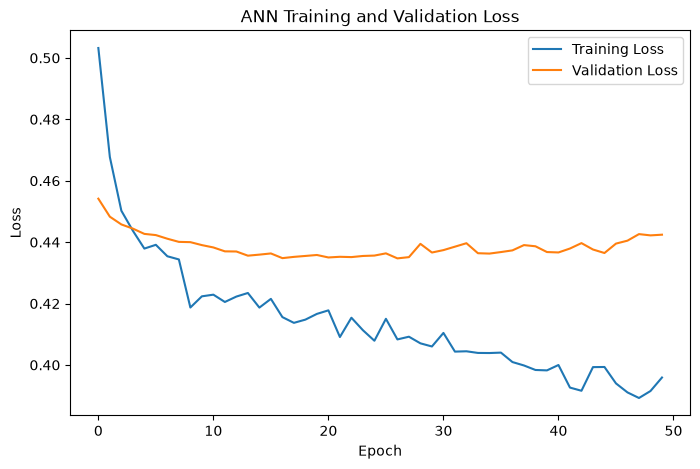

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("ANN Training and Validation Loss")

plt.legend()

plt.show()


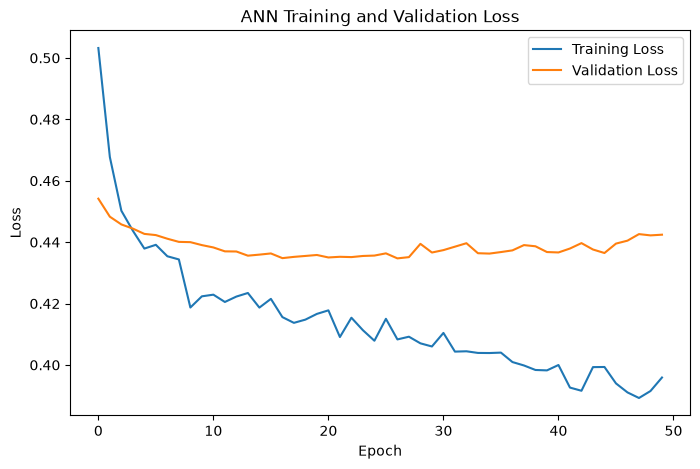

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("ANN Training and Validation Loss")

plt.legend()

plt.show()

In [19]:
start_time = time.time()

ann_probability = ann_model.predict(
    X_test_ann,
    verbose=0
).ravel()

ann_prediction_time = time.time() - start_time

print(
    "ANN prediction time:",
    ann_prediction_time,
    "seconds"
)

ANN prediction time: 0.5387508869171143 seconds


In [20]:
ann_prediction = (
    ann_probability >= 0.50
).astype(int)

In [21]:
ann_accuracy = accuracy_score(
    y_test_ann,
    ann_prediction
)

ann_precision = precision_score(
    y_test_ann,
    ann_prediction
)

ann_recall = recall_score(
    y_test_ann,
    ann_prediction
)

ann_f1 = f1_score(
    y_test_ann,
    ann_prediction
)

ann_roc_auc = roc_auc_score(
    y_test_ann,
    ann_probability
)

ann_pr_auc = average_precision_score(
    y_test_ann,
    ann_probability
)

In [22]:
ann_results = pd.DataFrame([{
    "Model": "ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1": ann_f1,
    "ROC-AUC": ann_roc_auc,
    "PR-AUC": ann_pr_auc,
    "Training Time": ann_training_time,
    "Prediction Time": ann_prediction_time
}])

ann_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,ANN,0.797729,0.632047,0.569519,0.599156,0.842597,0.631335,48.66928,0.538751


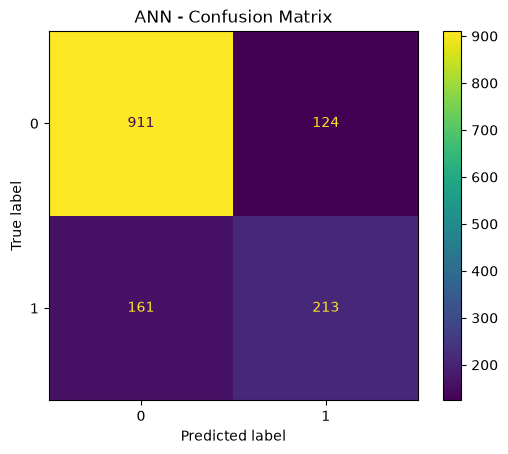

In [23]:
cm_ann = confusion_matrix(
    y_test_ann,
    ann_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ann
)

disp.plot()

plt.title("ANN - Confusion Matrix")

plt.show()

In [24]:
phase7_results = pd.read_csv(
    "../data/processed/phase7_final_comparison.csv"
)

phase7_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805
1,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941
2,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
5,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773
6,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618


In [25]:
ann_comparison = pd.concat(
    [
        phase7_results,
        ann_results
    ],
    ignore_index=True
)

ann_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805,NaN,NaN
1,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941,NaN,NaN
2,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789,NaN,NaN
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339,NaN,NaN
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283,NaN,NaN
5,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773,NaN,NaN
6,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618,NaN,NaN
7,ANN,0.797729,0.632047,0.569519,0.599156,0.842597,0.631335,48.66928,0.538751


In [26]:
ann_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773,NaN,NaN
1,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283,NaN,NaN
2,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805,NaN,NaN
3,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941,NaN,NaN
4,ANN,0.797729,0.632047,0.569519,0.599156,0.842597,0.631335,48.66928,0.538751
5,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789,NaN,NaN
6,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618,NaN,NaN
7,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339,NaN,NaN


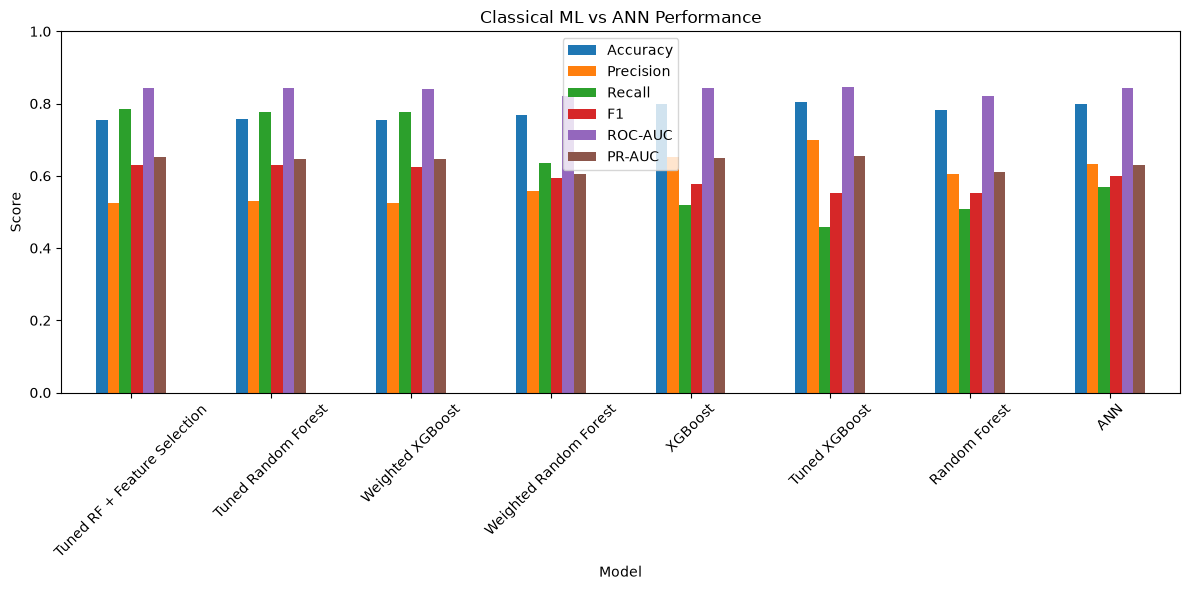

In [27]:
comparison_plot = ann_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Classical ML vs ANN Performance"
)

plt.ylabel("Score")

plt.xlabel("Model")

plt.xticks(rotation=45)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

In [28]:
ann_model.save(
    "../models/churn_ann.keras"
)

print("ANN model saved successfully.")

ANN model saved successfully.


In [29]:
joblib.dump(
    history.history,
    "../models/churn_ann_history.pkl"
)

print("ANN training history saved.")

ANN training history saved.


In [30]:
ann_comparison.to_csv(
    "../data/processed/ann_model_comparison.csv",
    index=False
)

print("ANN comparison saved.")

ANN comparison saved.
